In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
df = pd.read_csv("../data/processed.cleveland.data",
                 header=None, names=cols, na_values="?")
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
X = df.drop(columns=["target"]); y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_cols  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
onehot_cols = ["cp", "restecg", "thal"]
pass_cols   = ["sex", "fbs", "exang", "slope", "ca"]
preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), scale_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="first",
                                           handle_unknown="ignore"))]), onehot_cols),
    ("pass", SimpleImputer(strategy="most_frequent"), pass_cols),
])

# 最终模型：用第 5 周定选的模型和调好的参数（下面以逻辑回归为例，C 换成你的最佳值）
final_model = Pipeline([("prep", preprocess),
                        ("clf", LogisticRegression(max_iter=1000, C=1, random_state=42))])
final_model.fit(X_train, y_train)
proba = final_model.predict_proba(X_test)[:, 1]

D:\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
D:\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


In [2]:
fpr, tpr, thresholds = roc_curve(y_test, proba)
print("寻找敏感性 ≥ 0.90 的候选阈值：")
for t, sen, fp in zip(thresholds, tpr, fpr):
    if 0.90 <= sen <= 0.96:
        print(f"阈值={t:.3f} 敏感性={sen:.3f} 假阳性率={fp:.3f}")

寻找敏感性 ≥ 0.90 的候选阈值：
阈值=0.720 敏感性=0.929 假阳性率=0.030
阈值=0.427 敏感性=0.929 假阳性率=0.212


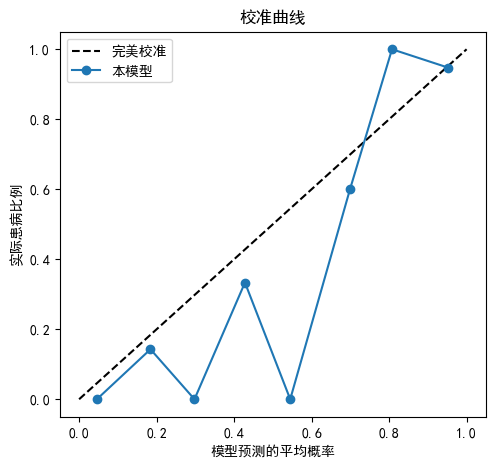

In [3]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=8)
plt.figure(figsize=(5.5, 5))
plt.plot([0, 1], [0, 1], "k--", label="完美校准")
plt.plot(prob_pred, prob_true, "o-", label="本模型")
plt.xlabel("模型预测的平均概率"); plt.ylabel("实际患病比例")
plt.legend(); plt.title("校准曲线")
plt.savefig("../figures/calibration.png", dpi=150); plt.show()

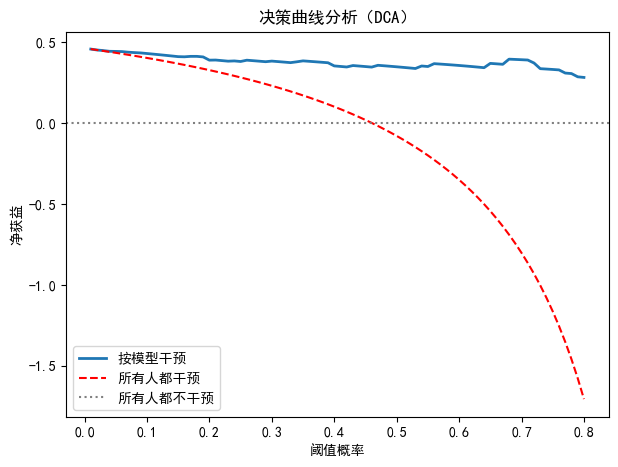

In [4]:
def decision_curve(y_true, proba, thresholds):
    n = len(y_true)
    net_benefit = []
    for pt in thresholds:
        pred = proba >= pt
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        net_benefit.append(tp / n - fp / n * pt / (1 - pt))
    return np.array(net_benefit)

pts = np.linspace(0.01, 0.8, 80)
nb_model = decision_curve(y_test.values, proba, pts)
prevalence = y_test.mean()
nb_all = prevalence - (1 - prevalence) * pts / (1 - pts)   # 所有人都干预

plt.figure(figsize=(7, 5))
plt.plot(pts, nb_model, label="按模型干预", lw=2)
plt.plot(pts, nb_all, "r--", label="所有人都干预")
plt.axhline(0, color="gray", ls=":", label="所有人都不干预")
plt.xlabel("阈值概率"); plt.ylabel("净获益")
plt.title("决策曲线分析（DCA）"); plt.legend()
plt.savefig("../figures/dca.png", dpi=150); plt.show()

In [5]:
THRESHOLD = 0.32   # ← 换成你选定的阈值

err = X_test.copy()
err["真实"] = y_test.values
err["预测概率"] = proba
err["预测"] = (proba >= THRESHOLD).astype(int)

fn = err[(err["真实"] == 1) & (err["预测"] == 0)]   # 漏诊的病人
fp = err[(err["真实"] == 0) & (err["预测"] == 1)]   # 误诊的健康人
print(f"漏诊 {len(fn)} 人，误诊 {len(fp)} 人")
print("=== 漏诊病例特征均值 ==="); print(fn.describe().T[["mean"]])
print("=== 误诊病例特征均值 ==="); print(fp.describe().T[["mean"]])
print("=== 全体测试集均值（对照） ==="); print(X_test.describe().T[["mean"]])

漏诊 1 人，误诊 9 人
=== 漏诊病例特征均值 ===
                mean
age        60.000000
sex         1.000000
cp          3.000000
trestbps  140.000000
chol      185.000000
fbs         0.000000
restecg     2.000000
thalach   155.000000
exang       0.000000
oldpeak     3.000000
slope       2.000000
ca          0.000000
thal        3.000000
真实          1.000000
预测概率        0.198996
预测          0.000000
=== 误诊病例特征均值 ===
                mean
age        57.444444
sex         0.888889
cp          3.000000
trestbps  135.777778
chol      232.000000
fbs         0.222222
restecg     1.111111
thalach   151.555556
exang       0.222222
oldpeak     0.766667
slope       1.555556
ca          1.000000
thal        5.555556
真实          0.000000
预测概率        0.548449
预测          1.000000
=== 全体测试集均值（对照） ===
                mean
age        54.000000
sex         0.672131
cp          3.180328
trestbps  134.590164
chol      234.213115
fbs         0.163934
restecg     1.032787
thalach   148.196721
exang       0.327869
oldpeak 